# **ASU CHM 343 Physical Chemistry Lab '2' - Notebook**

***Determination of Thermochemical Properties of Fatty Acids and Sugars by Using Simulated Bomb Calorimetry Data***

September 23, 2025

**Sebastian Raymundo**, sraymun1@asu.edu

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CHM343/Calorimetry/blob/main/Notebooks/Bomb_Cal_Simulation_Example_CHM343_Spring2025.ipynb)


# **Abstract**

# **Introduction**

# **Methods**

# **Setup Notebook Environment**

In [1]:
# Primary Python Libraries
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# **Data/Results**

---



This is simulation data obtained using the Calorimeter Code 3655 and uploaded to my public GitHub repo.

In [2]:
# Read in Bomb Cal Simulated Data

df_BenzoicAcid_3655 = pd.read_table('https://raw.githubusercontent.com/sraymundo15/sraymundo15/refs/heads/master/Calorimetry%20Lab/2025-09-18_data_benzoic_acid_cc3655.csv', sep = "," , header=11, skiprows=[11])
df_Naphthalene_3655 = pd.read_table('https://raw.githubusercontent.com/sraymundo15/sraymundo15/refs/heads/master/Calorimetry%20Lab/2025-09-18_data_naphthalene_cc3655.csv', sep = "," , header=11, skiprows=[11])
df_LauricAcid_3655 = pd.read_table('https://raw.githubusercontent.com/sraymundo15/sraymundo15/refs/heads/master/Calorimetry%20Lab/2025-09-18_data_lauric_acid_cc3655.csv', sep = "," , header=11, skiprows=[11])
df_b_d_Fructose_3655 = pd.read_table('https://raw.githubusercontent.com/sraymundo15/sraymundo15/refs/heads/master/Calorimetry%20Lab/2025-09-18_data_%CE%B2-d-fructose_cc3655.csv', sep = "," , header=11, skiprows=[11])

# Plotting and Analysis of Each Substance for Calorimeter Code 3655

Substances selected: Benzoic Acid, Naphthalene, Lauric Acid and β-d-Fructose

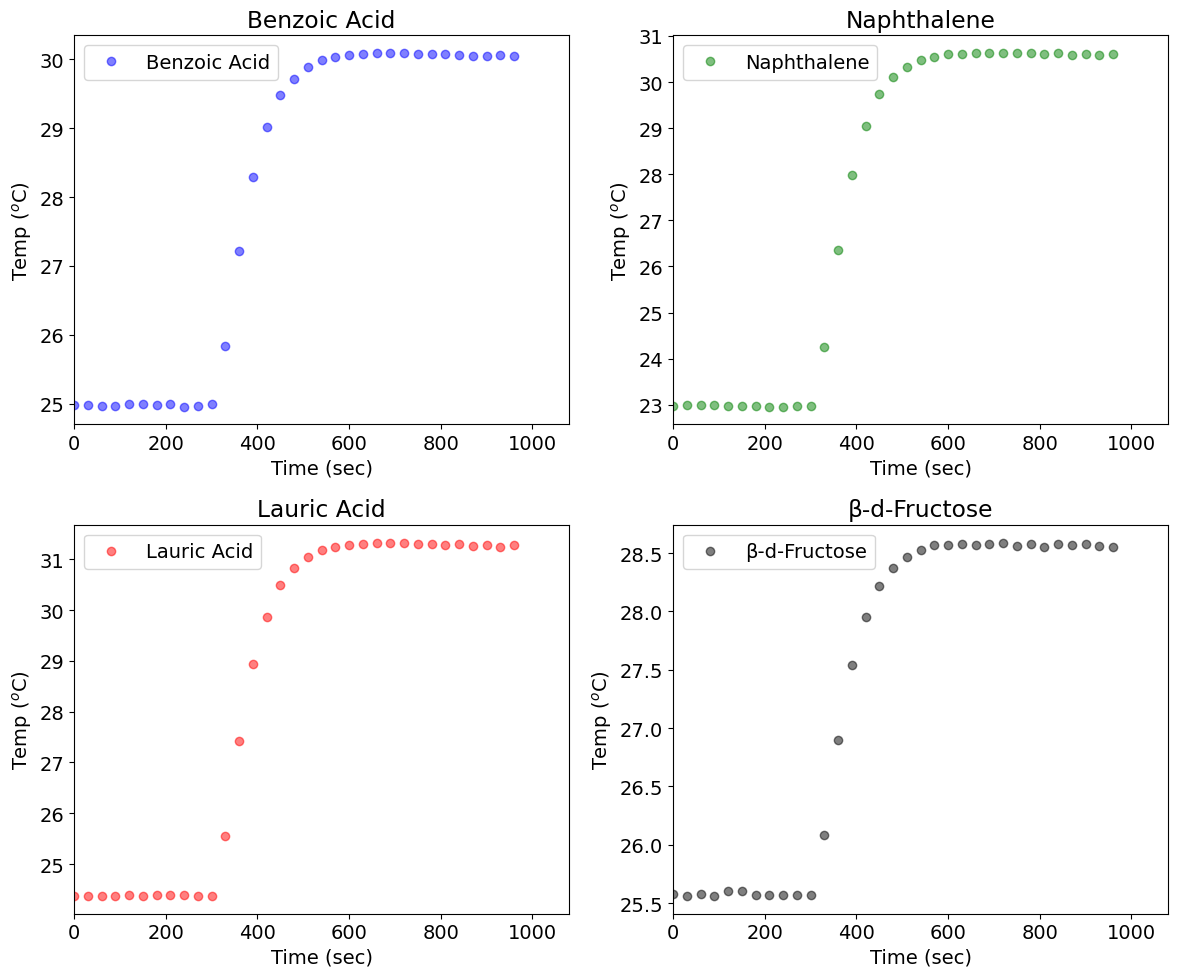

In [38]:
#@title Plots for Benzoic Acid, Naphthalene, Lauric Acid, and β-d-Fructose
# Initialize matplotlib subplot layout
fig, axes = plt.subplots(2,2, figsize=(12, 10))

# Set general font size
plt.rcParams['font.size'] = '14'

# Plot data
axes[0,0].plot(df_BenzoicAcid_3655['Time (s)'], df_BenzoicAcid_3655['Temperature (C)'], 'o', alpha=0.5, color = 'blue', label = 'Benzoic Acid')
axes[0,0].set_xlim(0, 1080)
axes[0,0].set_xlabel("Time (sec)", fontsize=14)
axes[0,0].set_ylabel("Temp ($^o$C)", fontsize=14)
axes[0,0].legend()

axes[0,1].plot(df_Naphthalene_3655['Time (s)'], df_Naphthalene_3655['Temperature (C)'], 'o', alpha=0.5, color = 'green', label = 'Naphthalene')
axes[0,1].set_xlim(0, 1080)
axes[0,1].set_xlabel("Time (sec)", fontsize=14)
axes[0,1].set_ylabel("Temp ($^o$C)", fontsize=14)
axes[0,1].legend()

axes[1,0].plot(df_LauricAcid_3655['Time (s)'], df_LauricAcid_3655['Temperature (C)'], 'o', alpha=0.5, color = 'red', label = 'Lauric Acid')
axes[1,0].set_xlim(0, 1080)
axes[1,0].set_xlabel("Time (sec)", fontsize=14)
axes[1,0].set_ylabel("Temp ($^o$C)", fontsize=14)
axes[1,0].legend()

axes[1,1].plot(df_b_d_Fructose_3655['Time (s)'], df_b_d_Fructose_3655['Temperature (C)'], 'o', alpha=0.5, color = 'black', label = 'β-d-Fructose')
axes[1,1].set_xlim(0, 1080)
axes[1,1].set_xlabel("Time (sec)", fontsize=14)
axes[1,1].set_ylabel("Temp ($^o$C)", fontsize=14)
axes[1,1].legend()

# Add titles to the plots
axes[0,0].set_title('Benzoic Acid')
axes[0,1].set_title('Naphthalene')
axes[1,0].set_title('Lauric Acid')
axes[1,1].set_title('β-d-Fructose')

# Display the plots for easy view (tightly but without losing information)
plt.tight_layout()
plt.show()

In [39]:
#@title Determine ΔT for Benzoic Acid, Naphthalene, Lauric Acid and β-d-Fructose
# Define number of points to consider
Number_Points = 10

# Linear Extrapolation of starting and ending

# Benzoic Acid
Bomb_Cal_BA_Initial = df_BenzoicAcid_3655[df_BenzoicAcid_3655.index.start:df_BenzoicAcid_3655.index.start+Number_Points]
Bomb_Cal_BA_Final = df_BenzoicAcid_3655[df_BenzoicAcid_3655.index.stop-1-Number_Points:df_BenzoicAcid_3655.index.stop-1]

# Naphthalene
Bomb_Cal_Naph_Initial = df_Naphthalene_3655[df_Naphthalene_3655.index.start:df_Naphthalene_3655.index.start+Number_Points]
Bomb_Cal_Naph_Final = df_Naphthalene_3655[df_Naphthalene_3655.index.stop-1-Number_Points:df_Naphthalene_3655.index.stop-1]

# Lauric Acid
Bomb_Cal_LA_Initial = df_LauricAcid_3655[df_LauricAcid_3655.index.start:df_LauricAcid_3655.index.start+Number_Points]
Bomb_Cal_LA_Final = df_LauricAcid_3655[df_LauricAcid_3655.index.stop-1-Number_Points:df_LauricAcid_3655.index.stop-1]

# β-d-Fructose
Bomb_Cal_BDF_Initial = df_b_d_Fructose_3655[df_b_d_Fructose_3655.index.start:df_b_d_Fructose_3655.index.start+Number_Points]
Bomb_Cal_BDF_Final = df_b_d_Fructose_3655[df_b_d_Fructose_3655.index.stop-1-Number_Points:df_b_d_Fructose_3655.index.stop-1]

# Linear fits for initial and final data points

# Benzoic Acid
mi_BA, bi_BA = np.polyfit(Bomb_Cal_BA_Initial['Time (s)'], Bomb_Cal_BA_Initial['Temperature (C)'], deg=1)
mf_BA, bf_BA = np.polyfit(Bomb_Cal_BA_Final['Time (s)'], Bomb_Cal_BA_Final['Temperature (C)'], deg=1)

# Naphthalene
mi_Naph, bi_Naph = np.polyfit(Bomb_Cal_Naph_Initial['Time (s)'], Bomb_Cal_Naph_Initial['Temperature (C)'], deg=1)
mf_Naph, bf_Naph = np.polyfit(Bomb_Cal_Naph_Final['Time (s)'], Bomb_Cal_Naph_Final['Temperature (C)'], deg=1)

# Lauric Acid
mi_LA, bi_LA = np.polyfit(Bomb_Cal_LA_Initial['Time (s)'], Bomb_Cal_LA_Initial['Temperature (C)'], deg=1)
mf_LA, bf_LA = np.polyfit(Bomb_Cal_LA_Final['Time (s)'], Bomb_Cal_LA_Final['Temperature (C)'], deg=1)

# β-d-Fructose
mi_BDF, bi_BDF = np.polyfit(Bomb_Cal_BDF_Initial['Time (s)'], Bomb_Cal_BDF_Initial['Temperature (C)'], deg=1)
mf_BDF, bf_BDF = np.polyfit(Bomb_Cal_BDF_Final['Time (s)'], Bomb_Cal_BDF_Final['Temperature (C)'], deg=1)

# Estimate Delta T from linear extrapolations
guess_temp = 375

# Benzoic Acid
dt_BA = ((bf_BA + mf_BA * guess_temp) - (bi_BA + mi_BA * guess_temp))

# Naphthalene
dt_Naph = ((bf_Naph + mf_Naph * guess_temp) - (bi_Naph + mi_Naph * guess_temp))

# Lauric Acid
dt_LA = ((bf_LA + mf_LA * guess_temp) - (bi_LA + mi_LA * guess_temp))

# β-d-Fructose
dt_BDF = ((bf_BDF + mf_BDF * guess_temp) - (bi_BDF + mi_BDF * guess_temp))

# Estimate Delta T from max/min

# Benzoic Acid
dt_BA_est = df_BenzoicAcid_3655['Temperature (C)'].max() - df_BenzoicAcid_3655['Temperature (C)'].min()

# Naphthalene
dt_Naph_est = df_Naphthalene_3655['Temperature (C)'].max() - df_Naphthalene_3655['Temperature (C)'].min()

# Lauric Acid
dt_LA_est = df_LauricAcid_3655['Temperature (C)'].max() - df_LauricAcid_3655['Temperature (C)'].min()

# β-d-Fructose
dt_BDF_est = df_b_d_Fructose_3655['Temperature (C)'].max() - df_b_d_Fructose_3655['Temperature (C)'].min()

# Estimate Delta T from linear extrapolations
guess_tmin = 300
guess_tmax = 500

# Benzoic Acid
dt_BA_min = ((bf_BA + mf_BA * guess_tmin) - (bi_BA + mi_BA * guess_tmin))
dt_BA_max = ((bf_BA + mf_BA * guess_tmax) - (bi_BA + mi_BA * guess_tmax))

# Naphthalene
dt_Naph_min = ((bf_Naph + mf_Naph * guess_tmin) - (bi_Naph + mi_Naph * guess_tmin))
dt_Naph_max = ((bf_Naph + mf_Naph * guess_tmax) - (bi_Naph + mi_Naph * guess_tmax))

# Lauric Acid
dt_LA_min = ((bf_LA + mf_LA * guess_tmin) - (bi_LA + mi_LA * guess_tmin))
dt_LA_max = ((bf_LA + mf_LA * guess_tmax) - (bi_LA + mi_LA * guess_tmax))

# β-d-Fructose
dt_BDF_min = ((bf_BDF + mf_BDF * guess_tmin) - (bi_BDF + mi_BDF * guess_tmin))
dt_BDF_max = ((bf_BDF + mf_BDF * guess_tmax) - (bi_BDF + mi_BDF * guess_tmax))

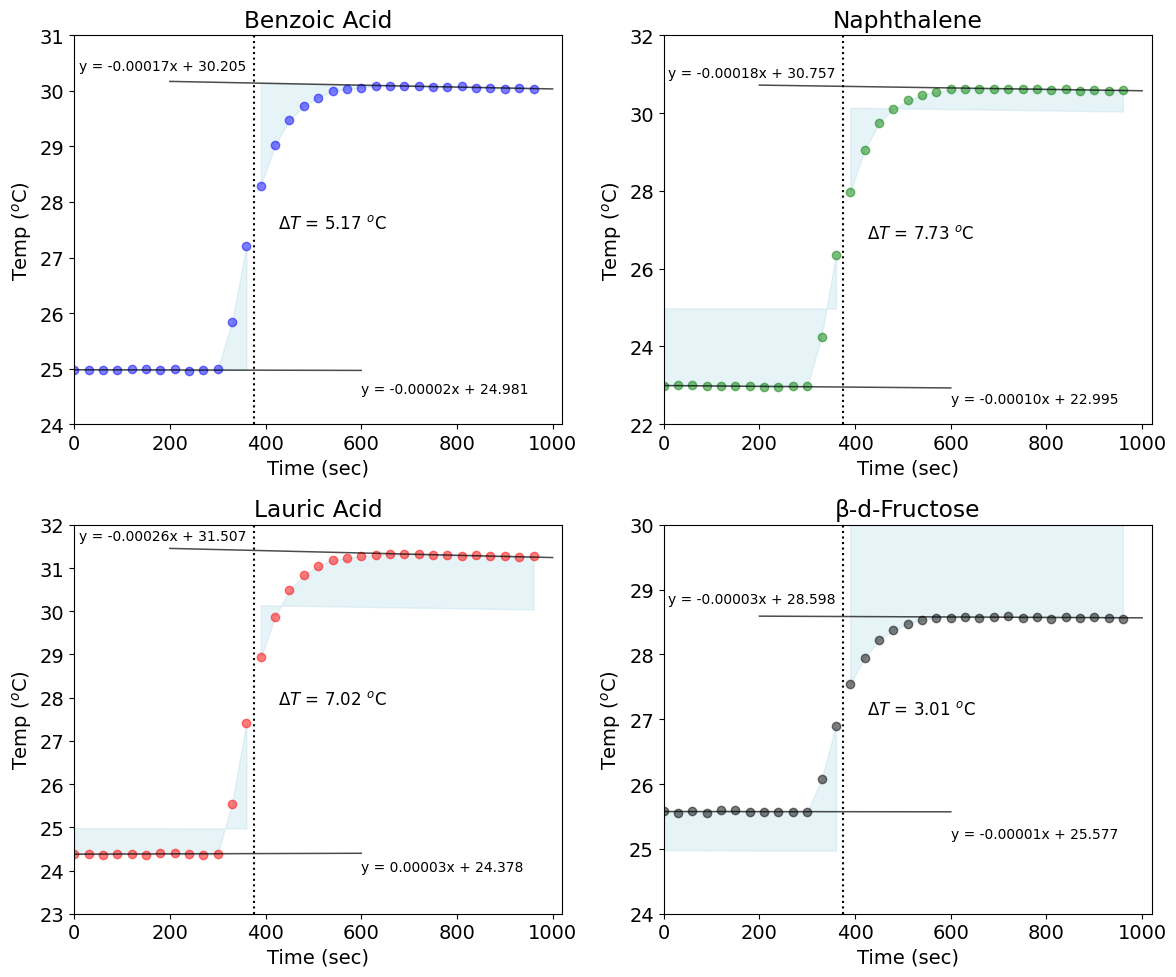

In [42]:
#@title Plot Data and ΔT Determination
# Initialize matplotlib subplot layout
fig, axes = plt.subplots(2,2, figsize=(12, 10))

# Set general font size
plt.rcParams['font.size'] = '14'

# Plot data
axes[0,0].plot(df_BenzoicAcid_3655['Time (s)'], df_BenzoicAcid_3655['Temperature (C)'], 'o', alpha=0.5, color = 'blue', label = 'Benzoic Acid')
axes[0,1].plot(df_Naphthalene_3655['Time (s)'], df_Naphthalene_3655['Temperature (C)'], 'o', alpha=0.5, color = 'green', label = 'Naphthalene')
axes[1,0].plot(df_LauricAcid_3655['Time (s)'], df_LauricAcid_3655['Temperature (C)'], 'o', alpha=0.5, color = 'red', label = 'Lauric Acid')
axes[1,1].plot(df_b_d_Fructose_3655['Time (s)'], df_b_d_Fructose_3655['Temperature (C)'], 'o', alpha=0.5, color = 'black', label = 'β-d-Fructose')

# Create linear sequences for fit lines
xseq_initial = np.linspace(0, 600, num=10)
xseq_final = np.linspace(200, 1000, num=10)

# Plot extrapolation lines

# Benzoic Acid
axes[0,0].plot(xseq_initial, bi_BA + mi_BA * xseq_initial, alpha=0.7, color="k", lw=1.1)
axes[0,0].plot(xseq_final, bf_BA + mf_BA * xseq_final, alpha=0.7, color="k", lw=1.1)

# Naphthalene
axes[0,1].plot(xseq_initial, bi_Naph + mi_Naph * xseq_initial, alpha=0.7, color="k", lw=1.1)
axes[0,1].plot(xseq_final, bf_Naph + mf_Naph * xseq_final, alpha=0.7, color="k", lw=1.1)

# Lauric Acid
axes[1,0].plot(xseq_initial, bi_LA + mi_LA * xseq_initial, alpha=0.7, color="k", lw=1.1)
axes[1,0].plot(xseq_final, bf_LA + mf_LA * xseq_final, alpha=0.7, color="k", lw=1.1)

# β-d-Fructose
axes[1,1].plot(xseq_initial, bi_BDF + mi_BDF * xseq_initial, alpha=0.7, color="k", lw=1.1)
axes[1,1].plot(xseq_final, bf_BDF + mf_BDF * xseq_final, alpha=0.7, color="k", lw=1.1)

# Draw a vertical line for temperature change

# Benzoic Acid
axes[0,0].axvline(x=guess_temp, color='k', linestyle='dotted')

# Naphthalene
axes[0,1].axvline(x=guess_temp, color='k', linestyle='dotted')

# Lauric Acid
axes[1,0].axvline(x=guess_temp, color='k', linestyle='dotted')

# β-d-Fructose
axes[1,1].axvline(x=guess_temp, color='k', linestyle='dotted')

# Fill between data and linear extrapolations

# Benzoic Acid
axes[0,0].fill_between(df_BenzoicAcid_3655['Time (s)'],bi_BA + mi_BA * df_BenzoicAcid_3655['Time (s)'], df_BenzoicAcid_3655['Temperature (C)'],where=df_BenzoicAcid_3655['Time (s)']<=guess_temp , interpolate=True, color='lightblue', alpha=0.3)
axes[0,0].fill_between(df_BenzoicAcid_3655['Time (s)'],bf_BA + mf_BA * df_BenzoicAcid_3655['Time (s)'], df_BenzoicAcid_3655['Temperature (C)'],where=df_BenzoicAcid_3655['Time (s)']>=guess_temp , interpolate=True, color='lightblue', alpha=0.3)

# Naphthalene
axes[0,1].fill_between(df_Naphthalene_3655['Time (s)'],bi_BA + mi_BA * df_Naphthalene_3655['Time (s)'], df_Naphthalene_3655['Temperature (C)'],where=df_Naphthalene_3655['Time (s)']<=guess_temp , interpolate=True, color='lightblue', alpha=0.3)
axes[0,1].fill_between(df_Naphthalene_3655['Time (s)'],bf_BA + mf_BA * df_Naphthalene_3655['Time (s)'], df_Naphthalene_3655['Temperature (C)'],where=df_Naphthalene_3655['Time (s)']>=guess_temp , interpolate=True, color='lightblue', alpha=0.3)

# Lauric Acid
axes[1,0].fill_between(df_LauricAcid_3655['Time (s)'],bi_BA + mi_BA * df_LauricAcid_3655['Time (s)'], df_LauricAcid_3655['Temperature (C)'],where=df_LauricAcid_3655['Time (s)']<=guess_temp , interpolate=True, color='lightblue', alpha=0.3)
axes[1,0].fill_between(df_LauricAcid_3655['Time (s)'],bf_BA + mf_BA * df_LauricAcid_3655['Time (s)'], df_LauricAcid_3655['Temperature (C)'],where=df_LauricAcid_3655['Time (s)']>=guess_temp , interpolate=True, color='lightblue', alpha=0.3)

# β-d-Fructose
axes[1,1].fill_between(df_b_d_Fructose_3655['Time (s)'],bi_BA + mi_BA * df_b_d_Fructose_3655['Time (s)'], df_b_d_Fructose_3655['Temperature (C)'],where=df_b_d_Fructose_3655['Time (s)']<=guess_temp , interpolate=True, color='lightblue', alpha=0.3)
axes[1,1].fill_between(df_b_d_Fructose_3655['Time (s)'],bf_BA + mf_BA * df_b_d_Fructose_3655['Time (s)'], df_b_d_Fructose_3655['Temperature (C)'],where=df_b_d_Fructose_3655['Time (s)']>=guess_temp , interpolate=True, color='lightblue', alpha=0.3)

# Annotate ΔT

# Benzoic Acid
axes[0,0].text(guess_temp+50, (df_BenzoicAcid_3655['Temperature (C)'].min() + (df_BenzoicAcid_3655['Temperature (C)'].max() - df_BenzoicAcid_3655['Temperature (C)'].min())/2), r'$\Delta T$ = {} $^o$C'.format(round(dt_BA, 2)), fontsize=12)

# Naphthalene
axes[0,1].text(guess_temp+50, (df_Naphthalene_3655['Temperature (C)'].min() + (df_Naphthalene_3655['Temperature (C)'].max() - df_Naphthalene_3655['Temperature (C)'].min())/2), r'$\Delta T$ = {} $^o$C'.format(round(dt_Naph, 2)), fontsize=12)

# Lauric Acid
axes[1,0].text(guess_temp+50, (df_LauricAcid_3655['Temperature (C)'].min() + (df_LauricAcid_3655['Temperature (C)'].max() - df_LauricAcid_3655['Temperature (C)'].min())/2), r'$\Delta T$ = {} $^o$C'.format(round(dt_LA, 2)), fontsize=12)

# β-d-Fructose
axes[1,1].text(guess_temp+50, (df_b_d_Fructose_3655['Temperature (C)'].min() + (df_b_d_Fructose_3655['Temperature (C)'].max() - df_b_d_Fructose_3655['Temperature (C)'].min())/2), r'$\Delta T$ = {} $^o$C'.format(round(dt_BDF, 2)), fontsize=12)

# Annotate regression lines with equations

# Benzoic Acid
axes[0,0].annotate(f'y = {mi_BA:.5f}x + {bi_BA:.3f}', xy=(xseq_initial[-1], bi_BA + mi_BA * xseq_initial[-1]), xytext=(600, bi_BA + mi_BA * xseq_initial[-1] - 0.4),fontsize=10)
axes[0,0].annotate(f'y = {mf_BA:.5f}x + {bf_BA:.3f}', xy=(xseq_final[0], bf_BA + mf_BA * xseq_final[0]), xytext=(10, bf_BA + mf_BA * xseq_final[0] + 0.2),fontsize=10)

# Naphthalene
axes[0,1].annotate(f'y = {mi_Naph:.5f}x + {bi_Naph:.3f}', xy=(xseq_initial[-1], bi_Naph + mi_Naph * xseq_initial[-1]), xytext=(600, bi_Naph + mi_Naph * xseq_initial[-1] - 0.4),fontsize=10)
axes[0,1].annotate(f'y = {mf_Naph:.5f}x + {bf_Naph:.3f}', xy=(xseq_final[0], bf_Naph + mf_Naph * xseq_final[0]), xytext=(10, bf_Naph + mf_Naph * xseq_final[0] + 0.2),fontsize=10)

# Lauric Acid
axes[1,0].annotate(f'y = {mi_LA:.5f}x + {bi_LA:.3f}', xy=(xseq_initial[-1], bi_LA + mi_LA * xseq_initial[-1]), xytext=(600, bi_LA + mi_LA * xseq_initial[-1] - 0.4),fontsize=10)
axes[1,0].annotate(f'y = {mf_LA:.5f}x + {bf_LA:.3f}', xy=(xseq_final[0], bf_LA + mf_LA * xseq_final[0]), xytext=(10, bf_LA + mf_LA * xseq_final[0] + 0.2),fontsize=10)

# β-d-Fructose
axes[1,1].annotate(f'y = {mi_BDF:.5f}x + {bi_BDF:.3f}', xy=(xseq_initial[-1], bi_BDF + mi_BDF * xseq_initial[-1]), xytext=(600, bi_BDF + mi_BDF * xseq_initial[-1] - 0.4),fontsize=10)
axes[1,1].annotate(f'y = {mf_BDF:.5f}x + {bf_BDF:.3f}', xy=(xseq_final[0], bf_BDF + mf_BDF * xseq_final[0]), xytext=(10, bf_BDF + mf_BDF * xseq_final[0] + 0.2),fontsize=10)

# Plot x and y axis min/max limits and x and y axis labels for the plot

# Benzoic Acid
axes[0,0].set_xlim(0, 1020)
axes[0,0].set_ylim(24, 31)
axes[0,0].set_xlabel("Time (sec)", fontsize=14)
axes[0,0].set_ylabel("Temp ($^o$C)", fontsize=14)

# Naphthalene
axes[0,1].set_xlim(0, 1020)
axes[0,1].set_ylim(22, 32)
axes[0,1].set_xlabel("Time (sec)", fontsize=14)
axes[0,1].set_ylabel("Temp ($^o$C)", fontsize=14)

# Lauric Acid
axes[1,0].set_xlim(0, 1020)
axes[1,0].set_ylim(23, 32)
axes[1,0].set_xlabel("Time (sec)", fontsize=14)
axes[1,0].set_ylabel("Temp ($^o$C)", fontsize=14)

# β-d-Fructose
axes[1,1].set_xlim(0, 1020)
axes[1,1].set_ylim(24, 30)
axes[1,1].set_xlabel("Time (sec)", fontsize=14)
axes[1,1].set_ylabel("Temp ($^o$C)", fontsize=14)


# Add titles to the plots
axes[0,0].set_title('Benzoic Acid')
axes[0,1].set_title('Naphthalene')
axes[1,0].set_title('Lauric Acid')
axes[1,1].set_title('β-d-Fructose')

# Display the plots for easy view (tightly but without losing information)
plt.tight_layout()
plt.show()

In [ ]:
#@title Calculate Calorimeter Constant
Hba = 26425
Hfe = 5858
Wba = 1.9730
Wfe = 0.024-0.018
Erel = (Hba*Wba)+(Hfe*Wfe)
Ceq = Erel/dt

print('Ceq =', round(Ceq,2))

Ceq = 10094.9


In [ ]:
#@title Horizontal Line Thermodynamic Estimate (Over-Estimate)
Ceq = Erel/dt_est
print('Ceq =', round(Ceq,2))

Ceq = 10169.92


In [ ]:
#@title Thermodynamic Estimate - Minimum and Maximum
Ceq_min = Erel/dt_min
Ceq_max = Erel/dt_max

print('Ceq,min =', round(Ceq_min,2), " ", 'Ceq,max =', round(Ceq_max,2))

Ceq,min = 10073.05   Ceq,max = 10131.53


## Error Analysis

Estimate the +/- randon statistical error based on error in simulated data and propagating this error to determination of Delta-T and subsequent Ceq.

# Naphthalene

## Error Analysis

Estimate the +/- randon statistical error based on error in simulated data and propagating this error to determination of Delta-T and subsequent Ceq.

# Lauric Acid

## Error Analysis

Estimate the +/- randon statistical error based on error in simulated data and propagating this error to determination of Delta-T and subsequent Ceq.

# β-d-Fructose

## Error Analysis

Estimate the +/- randon statistical error based on error in simulated data and propagating this error to determination of Delta-T and subsequent Ceq.